In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ai_burnout_human_ai_collaboration.csv')

In [3]:
df.head()

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,...,Deep_Work_Hours,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label
0,1,22,Finance,Accountant,0.1,5,4.2,2,9,10,...,3.4,21,6.4,4,6,5,3,0.74,76.0,No Risk
1,2,29,Creative,Copywriter,9.7,5,3.4,2,10,2,...,3.6,7,5.6,2,5,8,4,0.24,72.9,No Risk
2,3,39,Education,Curriculum Designer,16.0,4,3.5,2,5,5,...,4.5,10,6.5,4,8,3,2,0.22,61.8,At Risk
3,4,29,Healthcare,Physician,5.5,6,3.2,2,6,3,...,3.7,11,6.4,4,2,6,2,0.11,85.1,No Risk
4,5,33,Technology,Product Manager,10.9,2,2.5,1,9,4,...,3.0,17,5.6,3,7,8,1,0.50,70.5,No Risk


In [9]:
# Convert Burnout_Label to numeric
df['Burnout_Numeric'] = df['Burnout_Label'].map({'No Risk':0, 'At Risk': 1})    

In [10]:
df.head()

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,...,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label,Burnout_Numeric
0,1,22,Finance,Accountant,0.1,5,4.2,2,9,10,...,21,6.4,4,6,5,3,0.74,76.0,No Risk,0.0
1,2,29,Creative,Copywriter,9.7,5,3.4,2,10,2,...,7,5.6,2,5,8,4,0.24,72.9,No Risk,0.0
2,3,39,Education,Curriculum Designer,16.0,4,3.5,2,5,5,...,10,6.5,4,8,3,2,0.22,61.8,At Risk,1.0
3,4,29,Healthcare,Physician,5.5,6,3.2,2,6,3,...,11,6.4,4,2,6,2,0.11,85.1,No Risk,0.0
4,5,33,Technology,Product Manager,10.9,2,2.5,1,9,4,...,17,5.6,3,7,8,1,0.50,70.5,No Risk,0.0


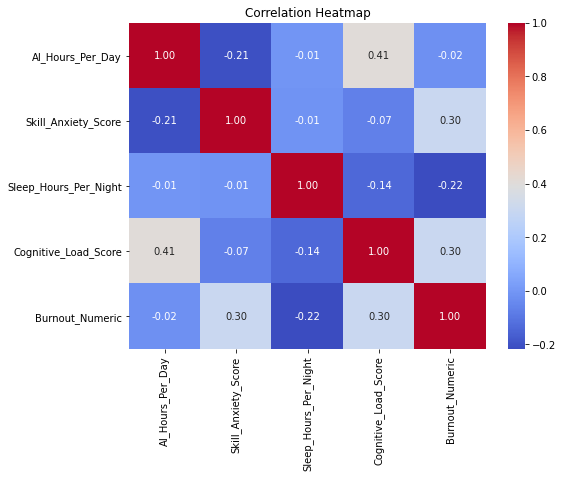

In [12]:
# Correlation heatmap between AI hour use, Sleep, Cognitive load, Replacement Anxiety and Burnout risk
correlation_matrix = df[['AI_Hours_Per_Day', 'Skill_Anxiety_Score', 'Sleep_Hours_Per_Night' , 'Cognitive_Load_Score', 'Burnout_Numeric']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Weak to moderate relationship between anxiety being replaced by AI and burnout risk, as well as between 
# Self-reported mental effort and sense of overload during work and burnout risk
# Weak negative relationship between Number of hours per day spent actively interacting with AI tools and burnout risk,
# suggesting using AI doesn't necessarily make employees more likely to get burnout, but the cognitive load may
# Negative correlation between sleep hours and burnout, showing sleep could act as a 'buffer' so more sleep could be related to less burnout risk

0.3378094282122983

0.21347470297639623

Career_Phase
Early Career    6.466776
Mid-Level       4.686951
Senior          4.220971
Veteran         3.926214
Name: Skill_Anxiety_Score, dtype: float64


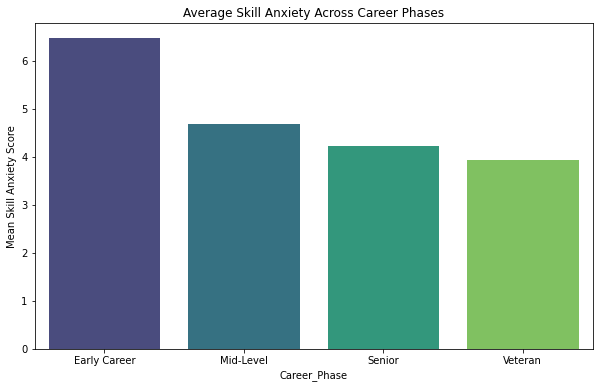

In [17]:
# See whether years of experience moderate the relationship between anxiety and burnout
# Create 4 career phases
df['Career_Phase'] = pd.cut(df['Years_Experience'], 
                            bins=[0, 5, 10, 20, 40], 
                            labels=['Early Career', 'Mid-Level', 'Senior', 'Veteran'])

# Average Anxiety for each phase
phase_analysis = df.groupby('Career_Phase')['Skill_Anxiety_Score'].mean()
print(phase_analysis)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_analysis.index, y=phase_analysis.values, palette='viridis')
plt.title('Average Anxiety Across Career Phases')
plt.ylabel('Mean Anxiety Score')
plt.show()

In [ ]:
# Descriptives showed that people in early career stage (0-5 years) had the highest AI replacement anxiety, could be 
# explained by the fact that they are new in building their professional identity and they don't have as much 
# instituional knowledge or expertise in their field of work yet

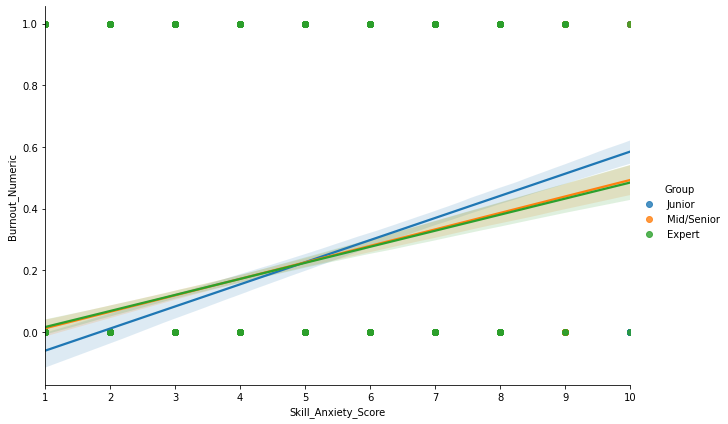

In [19]:
df['Group'] = 'Mid/Senior'

df.loc[df['Years_Experience'] < 5, 'Group'] = 'Junior'
df.loc[df['Years_Experience'] >= 15, 'Group'] = 'Expert'


sns.lmplot(
    data=df,
    x='Skill_Anxiety_Score',
    y='Burnout_Numeric',
    hue='Group', # Color points and regression lines by 'Condition'
    # col='Condition', # Alternatively, use 'col' to create separate plots for each condition
    height= 6, 
    aspect=1.5
)

In [ ]:
# At very low levels of AI anxiety, Junior actually feels 'safer', less burnout or more optimistic than Mid/Senior or Experts. 
# Mid/Senior and Experts even with low anxiety, might have a higher 'baseline' of burnout due to years to general workplace responsibility
# The slope for the Juniors is steeper than the peers, suggesting for each unit increase in their AI anxiety score, their probability of
# burnout climbs much faster. Specifically, when anxiety score reached between 4-5, Junior becomes the most at risk in burnout in the entire company
# Experts has the flattest slope among all, suggesting their burnout risk only increases marginally. This could mean that their other skills
# could make them feel indispensable despite the rise of AI.

In [ ]:
# Correlation calculations for junior and expert groups
junior['Skill_Anxiety_Score'].corr(junior['Burnout_Numeric'])
expert['Skill_Anxiety_Score'].corr(expert['Burnout_Numeric'])

In [ ]:
# While early-career employees (Juniors) report lower baseline burnout at low anxiety levels, they exhibit a visibly steeper burnout-response slope (r=0.34) compared with Veterans (r=0.21).
# This suggests that 'Transition' programs should not be one-size-fits-all. Juniors may require identity-anchoring interventions to prevent rapid burnout as AI adoption increases, 
# whereas Experts may benefit more from general stress management, as their burnout is less tied to specific AI skill-fear
